In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.31  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 31.7 GB RAM, 157.4/475.9 GB disk)


In [2]:
import torch
import cv2
import ultralytics
import roboflow
import inference_sdk

In [20]:
from inference_sdk import InferenceHTTPClient

CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="RqQEBE0zpu0utPao2x59"
)

result = CLIENT.infer("s.png", model_id="rock-paper-scissors-sxsw/14")
print(result)

{'inference_id': '20d9e548-f382-4b42-931f-e70e70ec3768', 'time': 0.010777092888019979, 'image': {'width': 511, 'height': 650}, 'predictions': []}


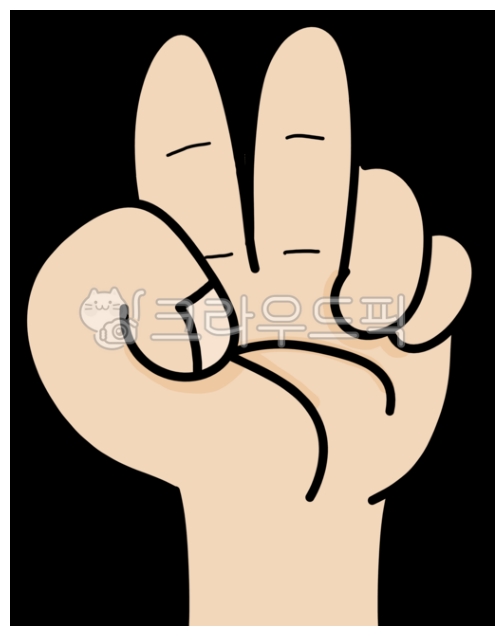

In [22]:
import cv2
import matplotlib.pyplot as plt

filename = 's.png'
result = CLIENT.infer(filename, model_id="rock-paper-scissors-sxsw/14")
img = cv2.imread(filename)

for pred in result["predictions"]:
    x, y = pred['x'], pred['y']
    width, height = pred['width'], pred['height']
    conf = pred['confidence']
    cls = pred['class']
    x1, y1 = int(x-width/2), int(y-height/2)
    x2, y2 = int(x+width/2), int(y+height/2)
    cv2.rectangle(img, (x1,y1), (x2, y2), (0,0,255), 2)
    cv2.putText(img, f'{cls} {conf:.4f}', (x1,y1), cv2.FONT_HERSHEY_PLAIN, 2, (0,0,255))

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [23]:
from roboflow import Roboflow
rf = Roboflow(api_key="wBMAwOTjgCJqAuQ8Zo2q")
project = rf.workspace("s-workspace-wf5aw").project("my-first-project-afory")
version = project.version(1)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-1 in yolov8:: 100%|██████████| 34/34 [00:00<00:00, 1642.00it/s]
